In [ ]:
import copy
import json
from os import path

import clustergram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from interpret.glassbox import ExplainableBoostingRegressor
from meteora import clients
from scipy import stats
from sklearn import linear_model, pipeline, preprocessing
from skops import io
from sktime.forecasting import auto_reg, compose

from swiss_lcd_heatwaves import plot_utils, regr_utils

# set seaborn style
sns.set_style("whitegrid")

In [ ]:
region = "Zollikofen"
ts_df_filepath = "../data/raw/parallel-2025-int.csv"

y_col = "$\\Delta$T"

# optional subset of station models to consider
# station_models = None
station_models = ["Abilium_2", "Barani", "Decentlab", "Koalasense", "Onset_big"]

# to save results
models_dir = "../models"
dst_station_model_dict_filepath = "../data/processed/station-model-dict.json"

# viz
col_wrap = 5
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

We first read the parallel LCD temperature measurements at Zollikofen:

In [ ]:
ts_df = (
    pd.read_csv(ts_df_filepath, parse_dates=["time"])
    .set_index("time")
    .resample("h")
    .mean()
)

all_station_models = [col for col in ts_df.columns if col != "Prof"]
if station_models is None:
    station_models = all_station_models
else:
    station_models = [
        station_model
        for station_model in station_models
        if station_model in all_station_models
    ]

ts_df = ts_df[["Prof"] + station_models]
ts_df.head()

,Prof,Abilium_2,Barani,Decentlab,Koalasense,Onset_big
time,,,,,,
2025-07-27 00:00:00,15.533333,15.053025,15.200000,NaN,15.133333,15.334000
2025-07-27 01:00:00,15.450000,14.956448,15.100000,NaN,14.983333,15.278667
2025-07-27 02:00:00,15.366667,14.934641,15.083333,NaN,14.950000,15.191000
2025-07-27 03:00:00,15.416667,14.929745,15.100000,NaN,14.983333,15.211000
2025-07-27 04:00:00,14.883333,14.434399,14.616667,NaN,14.466667,14.907667


The overall positive correlation in the plots suggests that the LCDs (with the exception of the Barani) tend to show a negative and positive temperature bias at lower and higher temperatures respectively.

In order to further explore the biases, we will now use [meteora](https://github.com/martibosch/meteora) to get the reference meteorological data from the MeteoSwiss Zollikofen (BER) station:

In [ ]:
client = clients.MeteoSwissClient(region)
ref_ts_df = (
    client.get_ts_df(
        [
            "temperature",
            "radiation_shortwave",
            "wind_speed",
            "wind_direction",
            "relative_humidity",
            "precipitation",
        ],
        start=ts_df.index.min(),
        end=ts_df.index.max(),
    )
    .droplevel("station_id")
    .resample("h")
    .mean()
)
ref_ts_df.head()

Stations:   0%|          | 0/1 [00:00<?, ?station/s]

,temperature,radiation_shortwave,wind_speed,wind_direction,relative_humidity,precipitation
time,,,,,,
2025-07-27 00:00:00,15.533333,0.000000,2.466667,172.333333,93.116667,0.000000
2025-07-27 01:00:00,15.450000,0.000000,2.616667,170.833333,93.316667,0.016667
2025-07-27 02:00:00,15.366667,0.000000,2.000000,175.500000,93.300000,0.000000
2025-07-27 03:00:00,15.416667,0.000000,2.016667,180.333333,92.516667,0.000000
2025-07-27 04:00:00,14.883333,11.166667,1.633333,200.833333,94.316667,0.000000


We now compute a time series with the *temperature biases* ($\Delta T$), i.e., difference between the temperature measurements at each LCD and the MeteoSwiss station into a long data frame:

In [ ]:
# get diff data in long form
long_ts_df = (
    ts_df.drop(columns="Prof")
    .sub(ts_df["Prof"], axis="rows")
    .rename_axis(columns="station_id")
    .stack()
    .rename(y_col)
    .reset_index()
)
long_ts_df.head()

,time,station_id,$\Delta$T
0,2025-07-27 00:00:00,Abilium_2,-0.480308
1,2025-07-27 00:00:00,Barani,-0.333333
2,2025-07-27 00:00:00,Koalasense,-0.400000
3,2025-07-27 00:00:00,Onset_big,-0.199333
4,2025-07-27 01:00:00,Abilium_2,-0.493552


Our main hypotheses are that:
- biases follow a daily cycle
- radiation is the main driver of the biases

Let us now plot the daily cycle of the average bias and radiation to test our hypothesis:

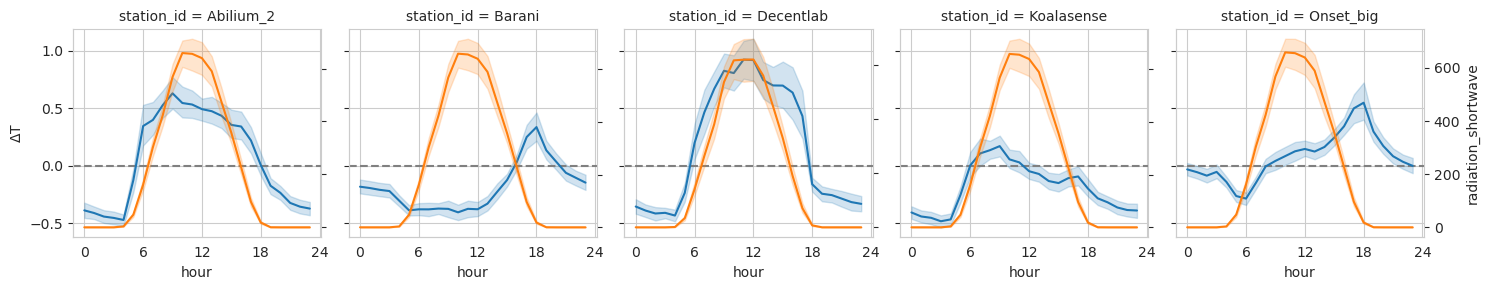

In [ ]:
variable = "radiation_shortwave"
daily_ts_df = (
    long_ts_df.set_index("time")
    .groupby("station_id")
    .resample("h")
    .mean()
    .reset_index()
)
daily_ts_df["hour"] = daily_ts_df["time"].dt.hour

g = plot_utils.facet_twinx_lineplot(
    daily_ts_df, ref_ts_df, variable, y_col, col_wrap=col_wrap
)

At a first glance, our hypothesis seems valid for all the LCDs with the exception of Barani and Onset big. However, for Abilium 2 black and Koalasense it seems that the effect of the radiation on $\Delta T$ is blocked at a certain point after which additional radiation does not result in higher biases. The confidence intervals are quite narrow which suggests that this pattern is consistent throughout our study period.

## Interlude: clustering days based on reference meteorological data to test bias consistency

To further confirm the consistency, we will cluster the days of our study period by their (standardize) time series of observation of the reference variables measured at the MeteoSwiss station:

K=1 skipped. Mean computed from data directly.
K=2 fitted in 0.008 seconds.
K=3 fitted in 0.002 seconds.
K=4 fitted in 0.002 seconds.
K=5 fitted in 0.002 seconds.
K=6 fitted in 0.002 seconds.
K=7 fitted in 0.002 seconds.


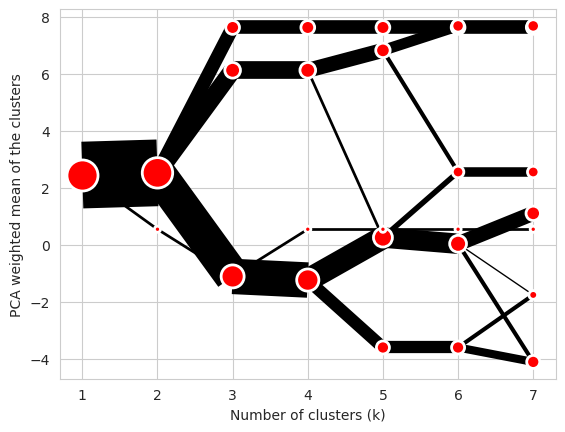

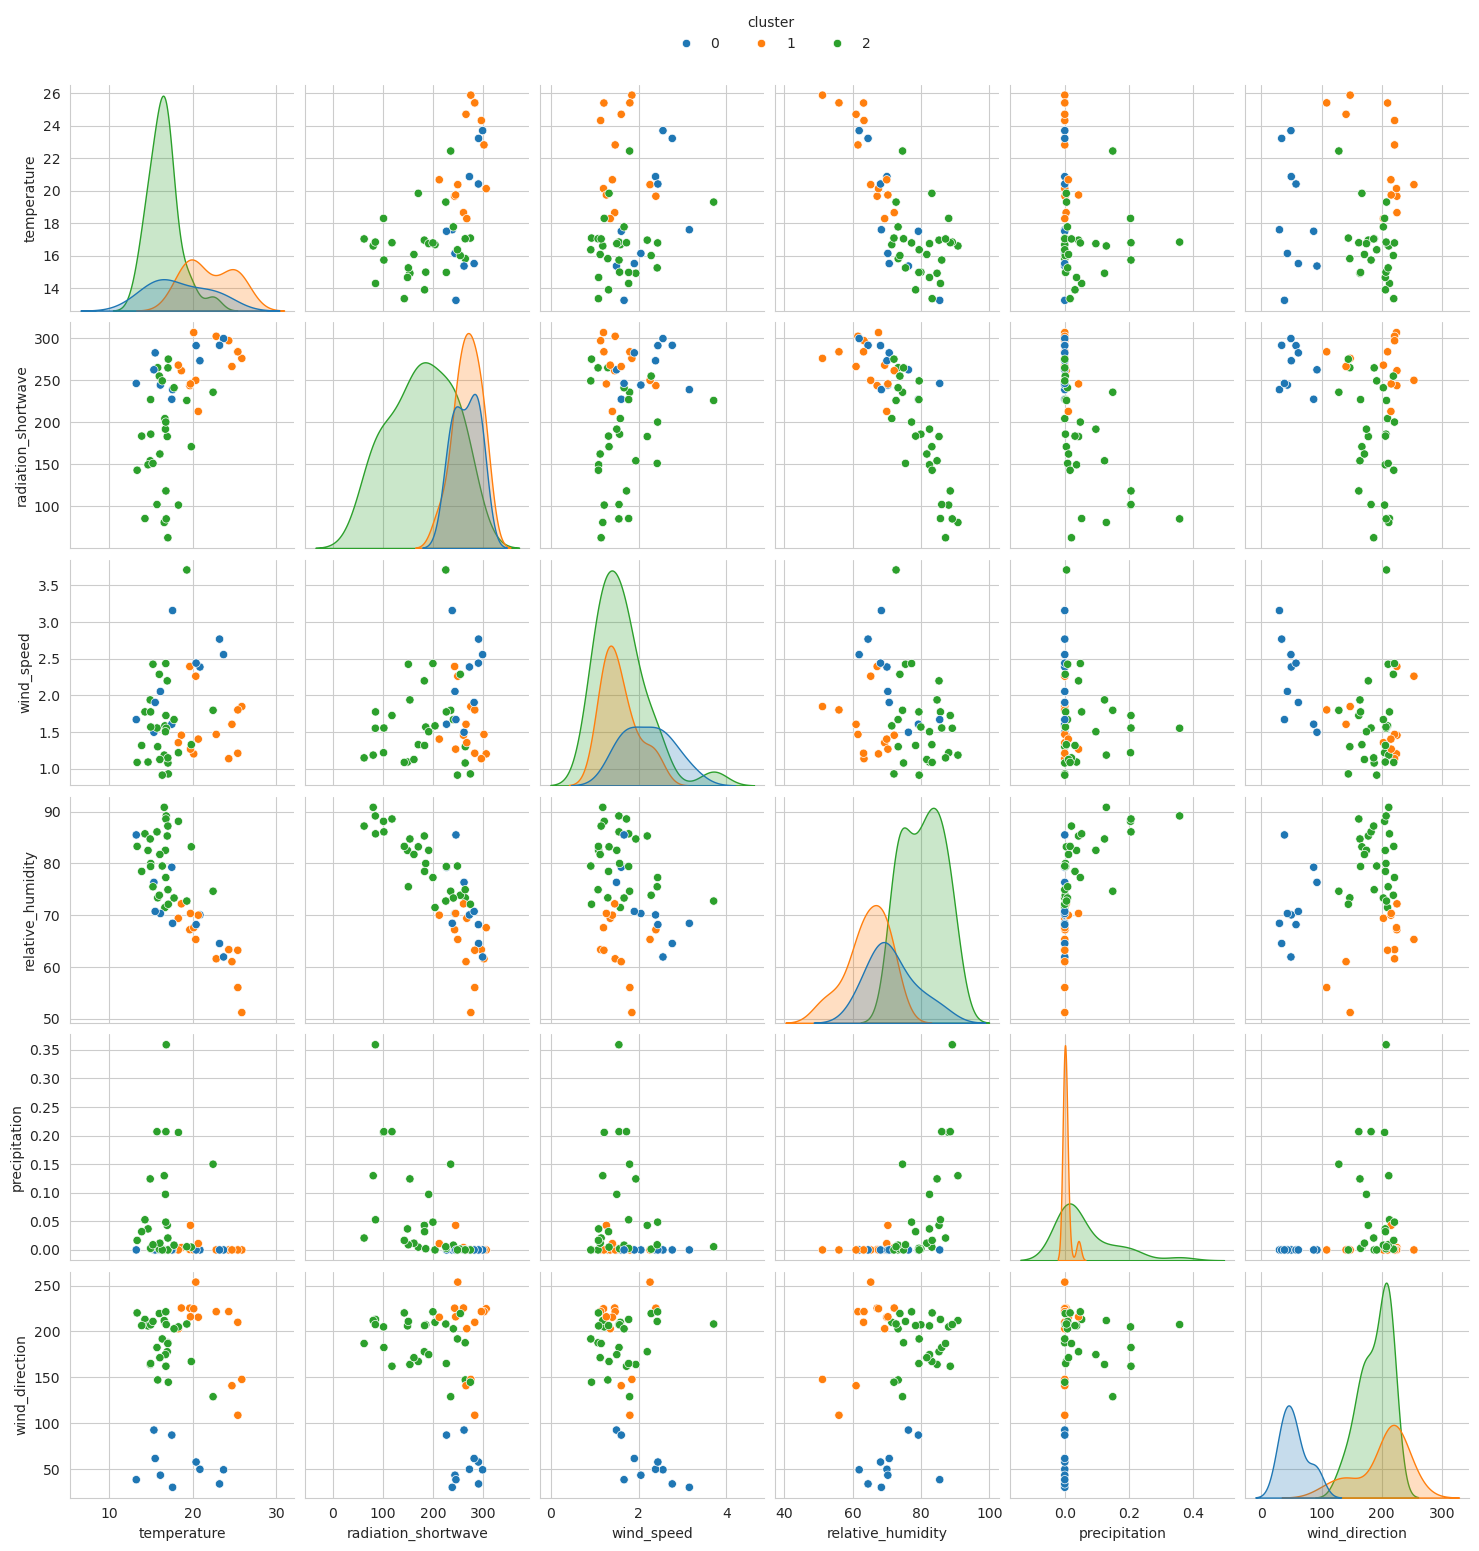

In [ ]:
# use circular representation for wind direction (degrees -> sin/cos)
wind_dir_rad_ser = np.deg2rad(ref_ts_df["wind_direction"])
cluster_input_df = ref_ts_df.drop(columns="wind_direction").assign(
    wind_direction_sin=np.sin(wind_dir_rad_ser),
    wind_direction_cos=np.cos(wind_dir_rad_ser),
)

X_ser = (
    pd.DataFrame(
        preprocessing.StandardScaler().fit_transform(cluster_input_df),
        index=cluster_input_df.index,
        columns=cluster_input_df.columns,
    )
    .groupby(cluster_input_df.index.date)
    .apply(lambda col_ser: col_ser.T.values)
    .apply(lambda arr: arr.flatten())
)
X_arr = np.stack(X_ser.values)
k_range = range(1, 8)
random_seed = 0
cgram = clustergram.Clustergram(k_range, random_state=random_seed).fit(X_arr)
cgram.plot()
score = cgram.davies_bouldin_score()
n_clusters = score.idxmax()
cluster_ser = pd.Series(cgram.labels_[n_clusters].values, index=X_ser.index)

# circular daily mean of wind direction
daily_plot_df = ref_ts_df.drop(columns="wind_direction").resample("d").mean()
daily_wind_df = (
    pd.DataFrame(
        {
            "wind_direction_sin": np.sin(wind_dir_rad_ser),
            "wind_direction_cos": np.cos(wind_dir_rad_ser),
        },
        index=ref_ts_df.index,
    )
    .resample("d")
    .mean()
)
daily_plot_df = daily_plot_df.assign(
    **{
        "wind_direction": np.mod(
            np.rad2deg(
                np.arctan2(
                    daily_wind_df["wind_direction_sin"],
                    daily_wind_df["wind_direction_cos"],
                )
            ),
            360,
        )
    }
).assign(**{"cluster": daily_plot_df.index.map(cluster_ser)})

g = sns.pairplot(
    daily_plot_df,
    hue="cluster",
    palette=sns.color_palette(n_colors=n_clusters),
)
sns.move_legend(
    g, "lower center", bbox_to_anchor=(0.5, 1), ncol=n_clusters, frameon=False
)

The clustering suggests three main types of days, namely:
- **cluster 0**: days with *mean circular wind direction under 100$\degree$ (coming from NE blowing toward SW)*
- **cluster 1**: days with mean circular wind direction over 100$\degree$ with *high mean temperature and radiation* and *low relative humidity*
- **cluster 2**: days with mean circular wind direction over 100$\degree$ with *low mean temperature and radiation* and *high relative humidity*

Let us now re-assess the daily cycle of $\Delta T$ for each day cluster:

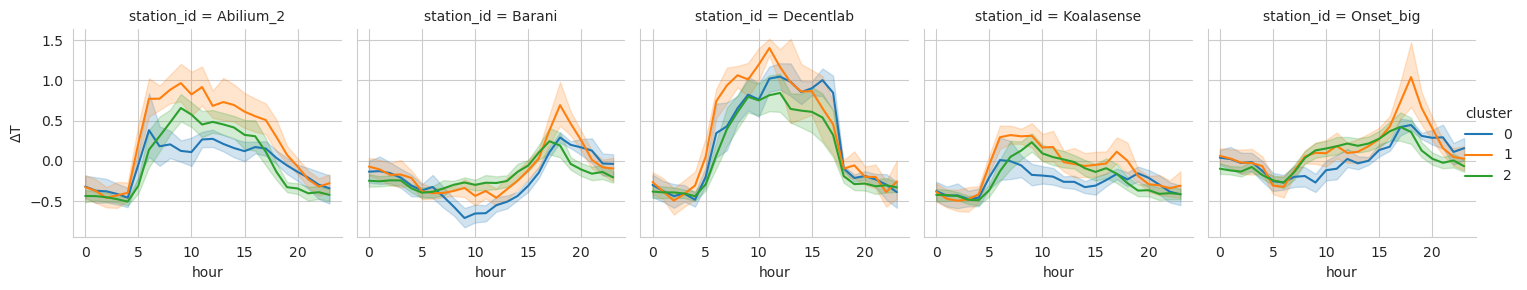

In [ ]:
g = sns.FacetGrid(
    daily_ts_df.assign(**{"cluster": daily_ts_df["time"].dt.date.map(cluster_ser)}),
    col="station_id",
    col_wrap=col_wrap,
    hue="cluster",
)
g.map_dataframe(sns.lineplot, x="hour", y=y_col)
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.96, 0.5))

There do not seem to be major differences in the $\Delta T$ daily cycle throughout day types.

## Modeling temperature biases based on radiation

We will now focus on modeling $\Delta T$ based on the (shortwave) radiation *for each LCD separately*. The rationale is that we expect each LCD to respond to radiation at different time lags and scales.

In line with Bell et al. (2015) [2], we will compute the sum of the previous radiation using different windows ranging from 1 to 5 hours and then, test which scale shows the highest correlation (based on the Pearson correlation coefficient) with $\Delta T$. Therefore, each LCD will have a dedicated model to predict its $\Delta T$ with the previous radiation (computed out of its *LCD-specific time window*) as independent variable.

In [ ]:
max_window_hours = 5
window_minutes = [60 * i for i in range(1, max_window_hours + 1)]

# For each station, fit BestScaleRadiationTransformer to select the best window
station_dfs = []
station_scale_dict = {}
for station_id, station_ts_df in long_ts_df.groupby("station_id"):
    X_raw = pd.DataFrame(
        {
            "time": station_ts_df["time"].values,
            "radiation_shortwave": station_ts_df["time"]
            .map(ref_ts_df["radiation_shortwave"])
            .values,
        }
    )
    y = station_ts_df[y_col].values

    transformer = regr_utils.BestScaleRadiationTransformer(window_minutes)
    transformer.fit(X_raw, y)
    station_scale_dict[station_id] = transformer.best_scale_

    X_rolled = transformer.transform(X_raw)
    station_dfs.append(
        pd.DataFrame(
            {
                "station_id": station_id,
                "time": station_ts_df["time"].values,
                y_col: y,
                "radiation_shortwave": X_rolled["radiation_shortwave"].values,
            }
        )
    )

X_df = pd.concat(station_dfs, ignore_index=True).dropna()

# Scaled copy for regression plots
X_scaled_df = X_df.copy()
X_scaled_df["radiation_shortwave"] = (
    X_df.groupby("station_id")["radiation_shortwave"]
    .apply(
        lambda ser: pd.Series(
            preprocessing.StandardScaler().fit_transform(ser.to_frame()).flatten(),
            index=ser.index,
        )
    )
    .reset_index(drop=True)
    .values
)
X_df.head()

,station_id,time,$\Delta$T,radiation_shortwave
0,Abilium_2,2025-07-27 00:00:00,-0.480308,0.000000
1,Abilium_2,2025-07-27 01:00:00,-0.493552,0.000000
2,Abilium_2,2025-07-27 02:00:00,-0.432026,0.000000
3,Abilium_2,2025-07-27 03:00:00,-0.486922,0.000000
4,Abilium_2,2025-07-27 04:00:00,-0.448934,11.166667


We can see the scale/previous window size (in minutes) selected for each station:

In [ ]:
station_scale_dict

{'Abilium_2': 60,
 'Barani': 300,
 'Decentlab': 120,
 'Koalasense': 60,
 'Onset_big': 300}

We can start with an ordinary-least squares (OLS) linear regression model:

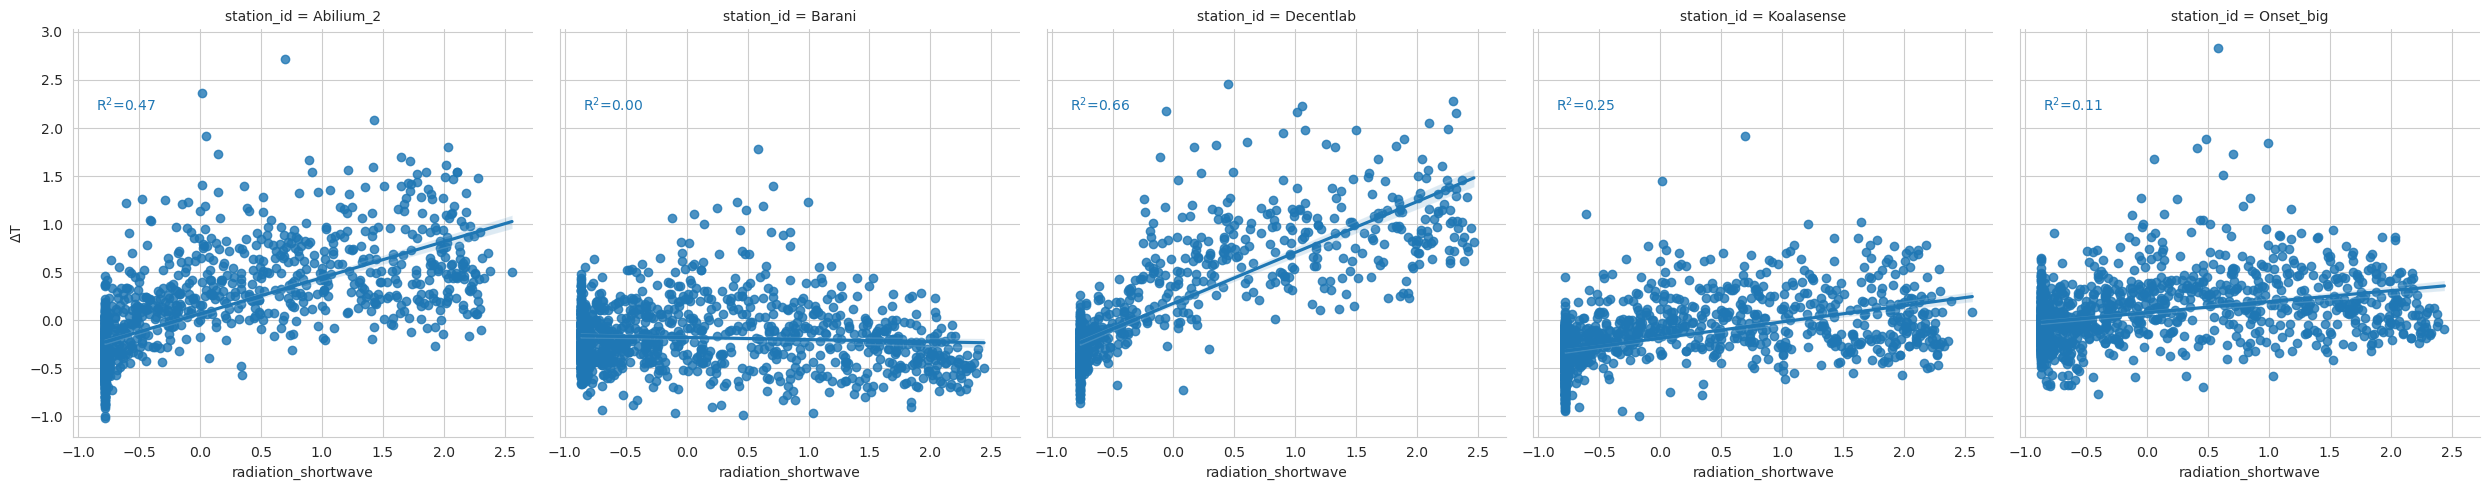

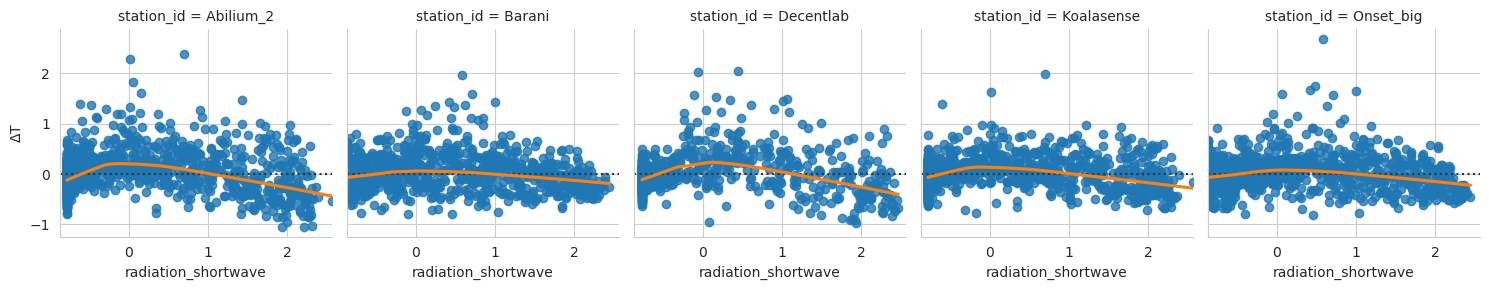

In [ ]:
# OLS
g = sns.lmplot(
    X_scaled_df,
    x="radiation_shortwave",
    y=y_col,
    col="station_id",
    col_wrap=col_wrap,
    # hue="cluster",
)
g.map_dataframe(plot_utils.r2_annotate, x="radiation_shortwave", y=y_col)
# g.add_legend()

# residuals
g = sns.FacetGrid(
    X_scaled_df,
    col="station_id",
    col_wrap=col_wrap,
    # hue="cluster",
)
g.map(
    sns.residplot,
    "radiation_shortwave",
    y_col,
    lowess=True,
    line_kws=dict(color=sns.color_palette()[1]),
)

As we can see, all models show a low to moderate fit with the exception of the Barani and Onset big, whose biases' daily cycle did not initially show a clear relationship with the radiation. The plots of the residuals suggest that there is still underlying structure (note the LOWESS curve [3], especially for the Onset small LCD), thus breaking the linear regression assumption that they are independent and identically distributed (i.i.d.).

We can also test fitting a separate model for each day cluster:

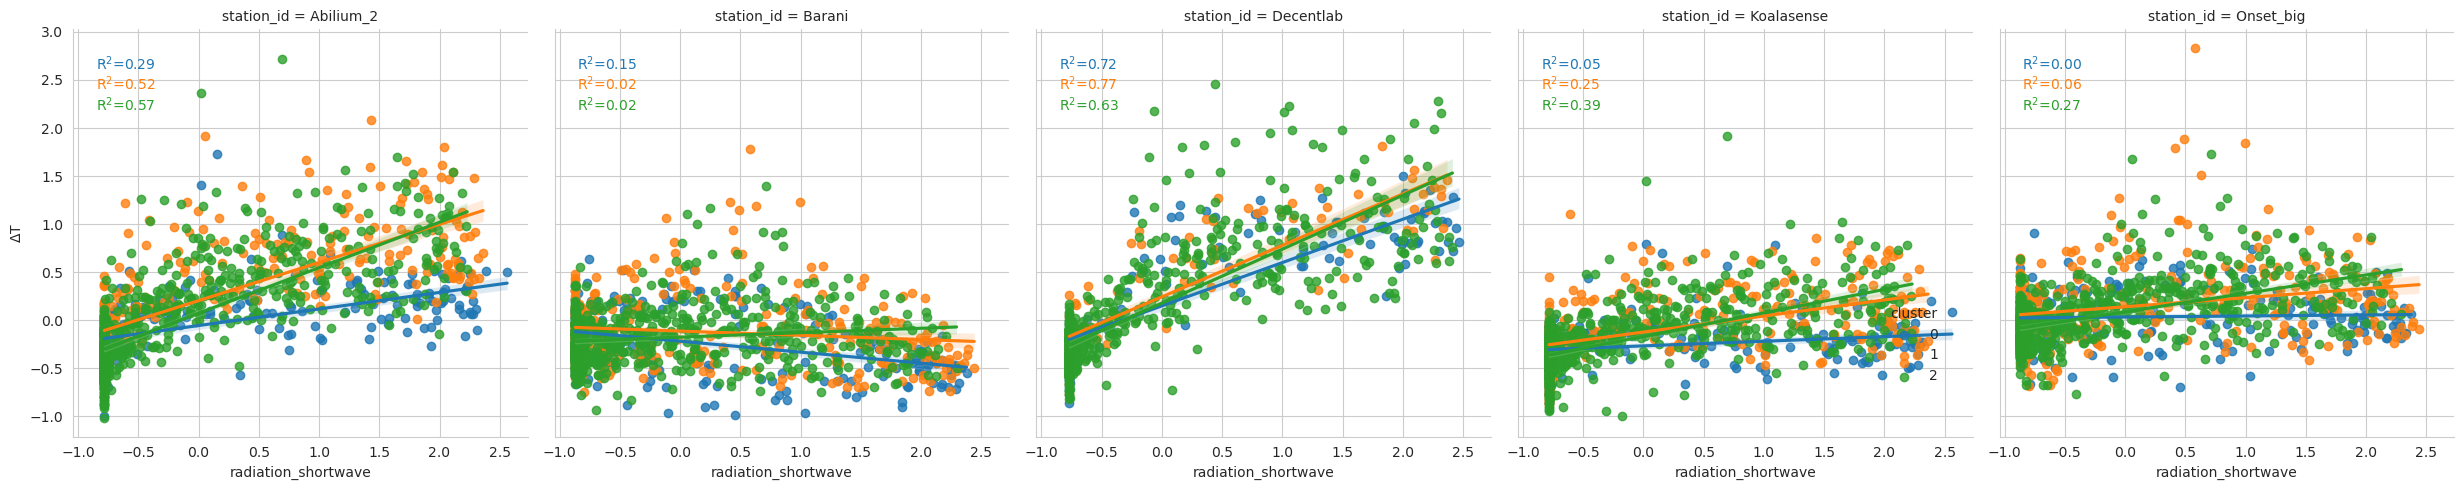

In [ ]:
# OLS by day cluster
plot_df = X_scaled_df.assign(**{"cluster": X_df["time"].dt.date.map(cluster_ser)})
g = sns.lmplot(
    plot_df,
    x="radiation_shortwave",
    y=y_col,
    col="station_id",
    col_wrap=col_wrap,
    hue="cluster",
)
g.map_dataframe(
    plot_utils.r2_annotate,
    x="radiation_shortwave",
    y=y_col,
    labels=plot_df["cluster"].unique(),
)
# g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.75, 0.3))

With the exception of the Barani and Decentlab LCDs, the OLS model seems to show the strongest fits for days with wind direction over 120$\degree$, i.e., clusters 1 and 2 (even though for the Onset small there is very little difference).

While the differences in the fits observed throughout day clusters may suggest non-linear relationships as well as effects of other variables, fitting a separate model for each day cluster may simply constitute an example of overfitting. Instead, following Cornes et al. (2020) [4], we can improve the models in two main ways. First, in order to better represent non-linear effects, we use an Explainable Boosting Machine (EBM) [5]. Like a classical GAM, the EBM learns a univariate shape function $f(\text{radiation})$ that is added to an intercept — in our single-predictor setting there are no pairwise interaction terms. The key difference from the B-spline GAM used by Cornes et al. is that the EBM learns the shape function via cyclic gradient boosting over small trees rather than penalized splines, which lets it adapt its complexity to the data without requiring manual specification of the number and placement of knots. Secondly, an autoregressive term can be added to the regression in order to address the temporal autocorrelation of the observations.

Note that the autoregressive term suggested by Cornes et al. (2020) relies on previously observed $\Delta T$ values, which are unavailable when applying the correction model to independently deployed LCD stations (where the true LCD–AWS difference is unknown). We therefore omit the autoregressive term from the final correction model, but include it in the comparison below (using a B-spline GAM as the base model) to confirm that it provides little to no performance gain.

Accordingly, let us compare the performance of:
- **OLS**: an univariate linear regression model
- **EBM**: an Explainable Boosting Machine [5]
- **GAM (AR)**: a B-spline GAM with an autoregressive term (included for reference only)

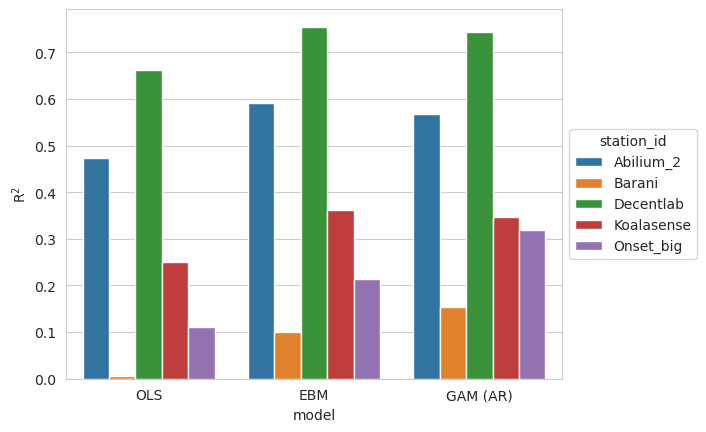

In [ ]:
# Define full pipelines
ols = pipeline.Pipeline(
    steps=[
        (
            "radiation_transformer",
            regr_utils.BestScaleRadiationTransformer(window_minutes),
        ),
        ("scaler", preprocessing.StandardScaler()),
        ("model", linear_model.LinearRegression()),
    ]
)
ebm = pipeline.Pipeline(
    steps=[
        (
            "radiation_transformer",
            regr_utils.BestScaleRadiationTransformer(window_minutes),
        ),
        ("model", ExplainableBoostingRegressor()),
    ]
)
# GAM-AR uses a ForecastingPipeline (sktime) which cannot include
# BestScaleRadiationTransformer, so it operates on the pre-rolled radiation
gam_ar = compose.ForecastingPipeline(
    steps=[
        ("scaler", preprocessing.StandardScaler()),
        ("spline", preprocessing.SplineTransformer(degree=3, n_knots=20)),
        ("model", auto_reg.AutoREG(lags=1, trend="c")),
    ]
)
model_dict = {"OLS": ols, "EBM": ebm, "GAM (AR)": gam_ar}

# Fit per station and compare
fit_dict = {}
fit_model_dict = {}
res_df = pd.DataFrame(index=X_df.index)
for station_id, station_x_df in X_df.groupby("station_id"):
    X_raw = pd.DataFrame(
        {
            "time": station_x_df["time"].values,
            "radiation_shortwave": station_x_df["time"]
            .map(ref_ts_df["radiation_shortwave"])
            .values,
        }
    )
    y_ser = station_x_df[y_col].reset_index(drop=True)
    station_index = station_x_df.index

    _fit_dict = {}
    _fit_model_dict = {}
    for label, model_pipeline in model_dict.items():
        _p = copy.deepcopy(model_pipeline)
        if isinstance(_p, compose.ForecastingPipeline):
            # ForecastingPipeline: use pre-rolled radiation from X_df
            X_pre = station_x_df[["radiation_shortwave"]].reset_index(drop=True)
            _p.fit(y_ser, X=X_pre)
            yhat = _p.predict(fh=list(range(1, len(y_ser) + 1)), X=X_pre)
        else:
            _p.fit(X_raw, y_ser)
            yhat = _p.predict(X_raw)
        _fit_dict[label] = stats.pearsonr(y_ser, yhat).statistic ** 2
        _fit_model_dict[label] = _p
        res_df.loc[station_index, label] = yhat

    fit_dict[station_id] = _fit_dict
    fit_model_dict[station_id] = _fit_model_dict

fit_df = pd.DataFrame(fit_dict).T.rename_axis("station_id")

# Plot comparison
ax = sns.barplot(
    fit_df.reset_index().melt(
        id_vars=["station_id"], var_name="model", value_name="R$^2$"
    ),
    x="model",
    y="R$^2$",
    hue="station_id",
)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

Using an EBM notably improves the strength of the fit, whereas further adding an autoregressive term results in better fit for some LCDs but worse for the rest.

Additionally, we can explore whether these improvements are consistent across the day clusters:

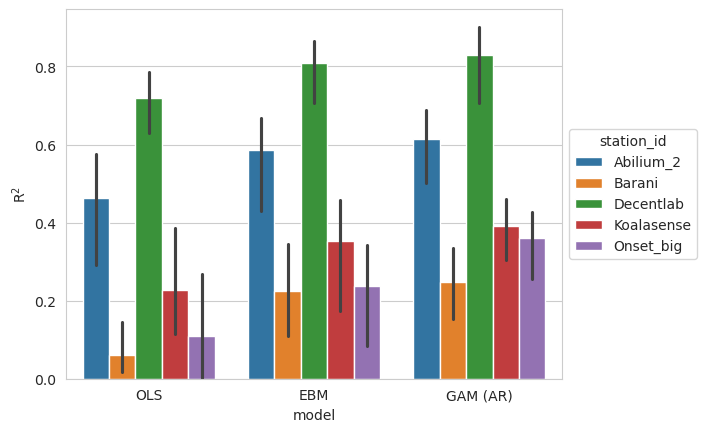

In [ ]:
fit_dfs = []
for cluster_label, cluster_df in X_df.groupby(X_df["time"].dt.date.map(cluster_ser)):
    _fit_dict = {}
    for station_id, station_df in cluster_df.groupby("station_id"):
        X_raw = pd.DataFrame(
            {
                "time": station_df["time"].values,
                "radiation_shortwave": station_df["time"]
                .map(ref_ts_df["radiation_shortwave"])
                .values,
            }
        )
        y_ser = station_df[y_col].reset_index(drop=True)
        _station_fit = {}
        for label, model_pipeline in model_dict.items():
            _p = copy.deepcopy(model_pipeline)
            if isinstance(_p, compose.ForecastingPipeline):
                X_pre = station_df[["radiation_shortwave"]].reset_index(drop=True)
                _p.fit(y_ser, X=X_pre)
                yhat = _p.predict(fh=list(range(1, len(y_ser) + 1)), X=X_pre)
            else:
                _p.fit(X_raw, y_ser)
                yhat = _p.predict(X_raw)
            _station_fit[label] = stats.pearsonr(y_ser, yhat).statistic ** 2
        _fit_dict[station_id] = _station_fit
    fit_dfs.append(
        pd.DataFrame(_fit_dict)
        .T.rename_axis("station_id")
        .assign(cluster_label=cluster_label)
    )
cluster_fit_df = pd.concat(fit_dfs)

ax = sns.barplot(
    cluster_fit_df.reset_index().melt(
        id_vars=["station_id", "cluster_label"],
        var_name="model",
        value_name="R$^2$",
    ),
    x="model",
    y="R$^2$",
    hue="station_id",
)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

It seems that the EBM consistently improves the strengths of the fits, while the autoregressive term has little effect (except for Onset big). We can further compare the OLS and the EBM models with (i) a scatter plot of the predicted versus observed values and (ii) a plot of the residuals against the radiation:

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_410875/486237705.py:4: SyntaxWarning: invalid escape sequence '\h'
  yhat_col = "$\hat{\Delta T}$"


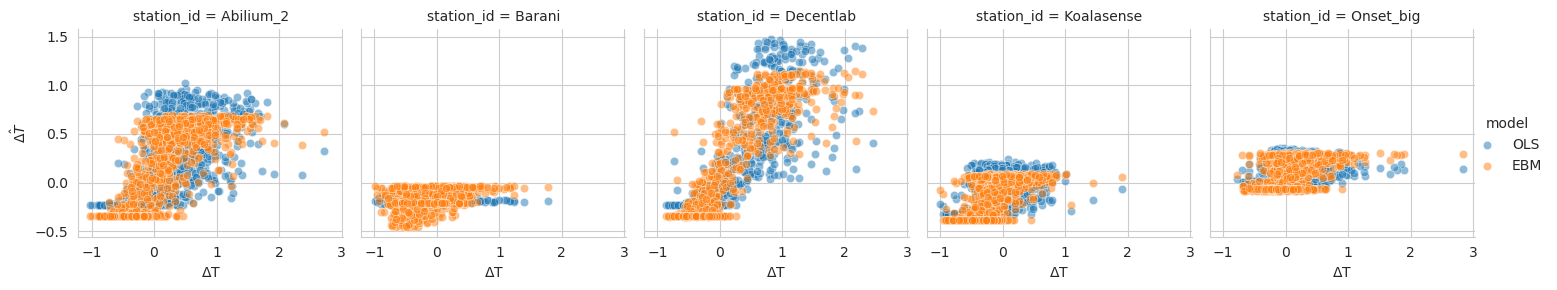

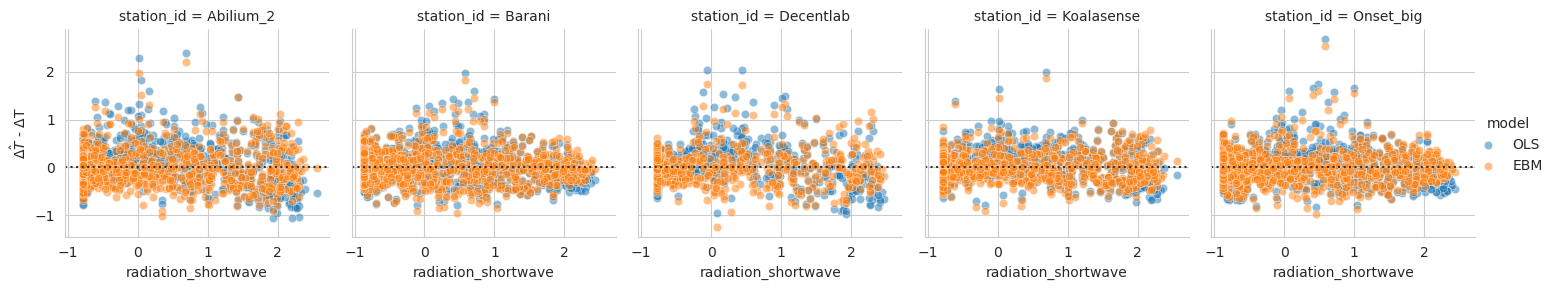

In [ ]:
id_vars = ["station_id", "radiation_shortwave", y_col]
var_name = "model"
model_cols = ["OLS", "EBM"]
yhat_col = "$\hat{\Delta T}$"
plot_df = res_df.assign(
    **{
        "station_id": X_df["station_id"],
        "radiation_shortwave": X_scaled_df["radiation_shortwave"],
        y_col: X_df[y_col],
    }
)
# obs/pred scatterplot
g = sns.FacetGrid(
    plot_df[id_vars + model_cols].melt(
        id_vars=id_vars,
        var_name=var_name,
        value_name=yhat_col,
    ),
    col="station_id",
    col_wrap=col_wrap,
    hue="model",
)
g.map(sns.scatterplot, y_col, yhat_col, alpha=0.5)
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.96, 0.5))

# residuals scatterplot
value_name = f"{yhat_col} - {y_col}"
g = sns.FacetGrid(
    plot_df.assign(
        **{model: plot_df[y_col] - plot_df[model] for model in model_cols},
    )[id_vars + model_cols].melt(
        id_vars=id_vars, var_name="model", value_name=value_name
    ),
    col="station_id",
    col_wrap=col_wrap,
    hue="model",
)
g.map(sns.scatterplot, "radiation_shortwave", value_name, alpha=0.5)
# add line at 0
for ax in g.axes.flat:
    ax.axhline(0, ls=":", c=".2")
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.96, 0.5))

We can visually confirm that the EBM model shows a better fit and removes structure from the residuals. Let us conclude by showing the daily cycle of the observed and predicted biases:

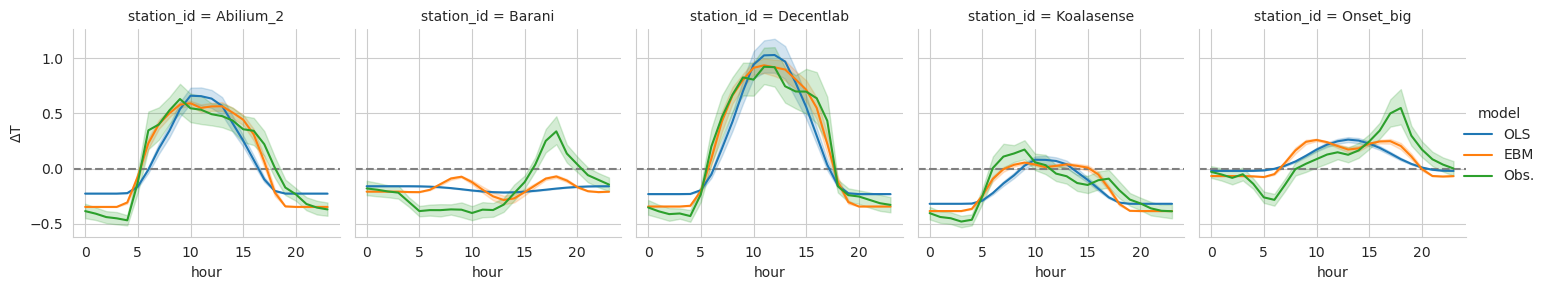

In [ ]:
g = sns.FacetGrid(
    pd.concat(
        [
            plot_df.assign(**{"time": X_df["time"]}).set_index(["station_id", "time"])[
                model_cols
            ],
            daily_ts_df.set_index(["station_id", "time"])[[y_col, "hour"]].rename(
                columns={y_col: "Obs."}
            ),
        ],
        axis="columns",
    )
    .reset_index()
    .melt(id_vars=["station_id", "time", "hour"], var_name="model", value_name=y_col),
    col="station_id",
    hue="model",
    col_wrap=col_wrap,
)
for ax in g.axes.flat:
    # add horizontal line at 0
    ax.axhline(0, color="gray", linestyle="--")
g.map(sns.lineplot, "hour", y_col)
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.96, 0.5))

We can observe also here that the daily cycle of the EBM predictions is closer to the observed values than its OLS counterparts (yet it still fails to reproduce the observed afternoon peak for the Barani and Onset bit LCDs).

Accordingly, *for each station* we will save the EBM pipeline to disk so that we can use them to correct radiative biases in separate notebooks:

In [ ]:
station_model_dict = {}
for station_id, _model_dict in fit_model_dict.items():
    ebm_pipeline = _model_dict["EBM"]
    best_scale = ebm_pipeline.named_steps["radiation_transformer"].best_scale_

    model_filename = f"{station_id}-ebm.skops"
    model_filepath = path.join(models_dir, model_filename)
    io.dump(ebm_pipeline, model_filepath)
    print(f"{station_id} (best scale = {best_scale} min) -> saved to {model_filepath}")
    station_model_dict[station_id] = model_filename

with open(dst_station_model_dict_filepath, "w") as dst:
    json.dump(station_model_dict, dst)

# Show types that need to be trusted when loading with skops
untrusted = io.get_untrusted_types(file=model_filepath)
print(f"\nSKOPS untrusted types (add to SKOPS_TRUSTED in apply notebook):\n{untrusted}")

Abilium_2 (best scale = 60 min) -> saved to ../models/Abilium_2-ebm.skops
Barani (best scale = 300 min) -> saved to ../models/Barani-ebm.skops
Decentlab (best scale = 120 min) -> saved to ../models/Decentlab-ebm.skops
Koalasense (best scale = 60 min) -> saved to ../models/Koalasense-ebm.skops
Onset_big (best scale = 300 min) -> saved to ../models/Onset_big-ebm.skops

SKOPS untrusted types (add to SKOPS_TRUSTED in apply notebook):
['interpret.glassbox._ebm._ebm.ExplainableBoostingRegressor', 'swiss_lcd_heatwaves.regr_utils.BestScaleRadiationTransformer']


## References

1. Bailey, E., Fuhrmann, C., Runkle, J., Stevens, S., Brown, M., & Sugg, M. (2020). Wearable sensors for personal temperature exposure assessments: a comparative study. Environmental research, 180, 108858.
2. Bell, S., Cornford, D., & Bastin, L. (2015). How good are citizen weather stations? Addressing a biased opinion. Weather, 70(3), 75-84.
3. Cleveland, W. S. (1979). Robust locally weighted regression and smoothing scatterplots. Journal of the American statistical association, 74(368), 829-836.
4. Cornes, R. C., Dirksen, M., & Sluiter, R. (2020). Correcting citizen‐science air temperature measurements across the Netherlands for short wave radiation bias. Meteorological Applications, 27(1), e1814.
5. Lou, Y., Caruana, R., Gehrke, J., & Hooker, G. (2013). Accurate Intelligible Models with Pairwise Interactions. In Proceedings of the 19th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 623–631).